## Loan Model Validation

In [12]:
from quant_slc_hedging.data_model import LoanModelInputs, SalaryModelInputs, SalaryGrowthType, salary_growth_amounts
from quant_slc_hedging.salary import SalaryModel
from quant_slc_hedging.loan import LoanModel
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

## Test 1 - No repayment, known interest

In [ ]:
# 60,000 balance, below threshold
# No repayment, interest at 3pct
# After year 1 balance = 60,000 + 60,000 * 3pct = 61,800

config = LoanModelInputs(
    initial_loan_balance=60_000,
    remaining_loan_term_months=30 * 12,
    max_loan_term_months= 30 * 12,
    base_interest_rate= 0.03,
    interest_rate_spread=0.03,
    repayment_amount_pct_salary= 0.09,
    repayment_threshold= 29_385,
    interest_rate_spread_threshold=52_885
)
sp = np.full((1_000, 360), 45_000)
lm = LoanModel(config)
lp = lm.generate_loan_paths(sp)

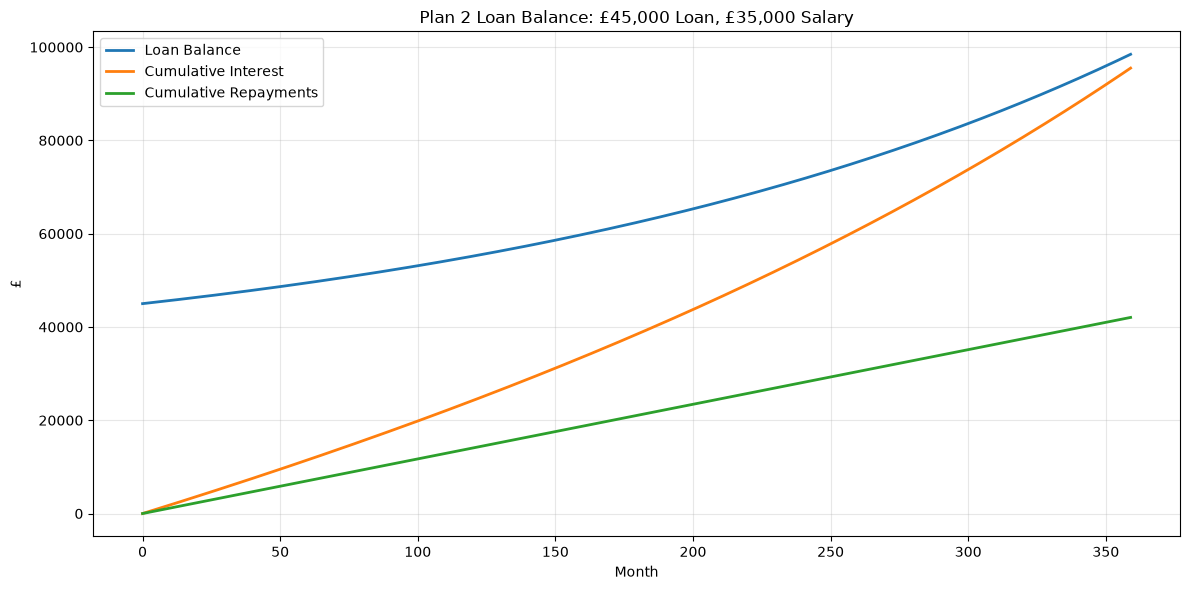

## Repayment threshold

In [ ]:
# 60,000 balance, above top threshold
# Repayment, 6% interest rate
# Base repayment of 9pct * (52,885 - 29,385) a year

config = LoanModelInputs(
    initial_loan_balance=60_000,
    remaining_loan_term_months=30 * 12,
    max_loan_term_months= 30 * 12,
    base_interest_rate= 0.03,
    interest_rate_spread=0.03,
    repayment_amount_pct_salary= 0.09,
    repayment_threshold= 29_385,
    interest_rate_spread_threshold=52_885
)
sp = np.full((1_000, 360), 52_885)
lm = LoanModel(config)
lp = lm.generate_loan_paths(sp)

In [18]:
lp.base_repayment[0][1] == (0.09 * (52885 - 29385))/12

np.True_

## Mid point between the thresholds

In [19]:
# 60,000 balance, between threshold
# Repayment, 3%+1.5% interest rate
# Base repayment of 9pct * (52,885 - 29,385) a year

config = LoanModelInputs(
    initial_loan_balance=60_000,
    remaining_loan_term_months=30 * 12,
    max_loan_term_months= 30 * 12,
    base_interest_rate= 0.03,
    interest_rate_spread=0.03,
    repayment_amount_pct_salary= 0.09,
    repayment_threshold= 29_385,
    interest_rate_spread_threshold=52_885
)
sp = np.full((1_000, 360), 41_135)
lm = LoanModel(config)
lp = lm.generate_loan_paths(sp)

In [22]:
lp.base_repayment[0][1] == (0.09 * (41_135 - 29_385))/12

np.True_

## Loan repays 

In [23]:
config = LoanModelInputs(
    initial_loan_balance=10_000,
    remaining_loan_term_months=30 * 12,
    max_loan_term_months= 30 * 12,
    base_interest_rate= 0.03,
    interest_rate_spread=0.03,
    repayment_amount_pct_salary= 0.09,
    repayment_threshold= 29_385,
    interest_rate_spread_threshold=52_885
)
sp = np.full((1_000, 360), 41_135)
lm = LoanModel(config)
lp = lm.generate_loan_paths(sp)

In [29]:
np.where(lp.loan_balance[0,:]==0)

(array([148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160,
        161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173,
        174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186,
        187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199,
        200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212,
        213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225,
        226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238,
        239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251,
        252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264,
        265, 266, 267, 268, 269, 270, 271, 272, 273, 274, 275, 276, 277,
        278, 279, 280, 281, 282, 283, 284, 285, 286, 287, 288, 289, 290,
        291, 292, 293, 294, 295, 296, 297, 298, 299, 300, 301, 302, 303,
        304, 305, 306, 307, 308, 309, 310, 311, 312, 313, 314, 315, 316,
        317, 318, 319, 320, 321, 322, 323, 324, 325

## Loan balance and interest paths when salary is above the min payment threshold

In [ ]:
config = LoanModelInputs(
    initial_loan_balance=45_000,
    remaining_loan_term_months=30 * 12,
    max_loan_term_months= 30 * 12,
    base_interest_rate= 0.03,
    interest_rate_spread=0.03,
    repayment_amount_pct_salary= 0.09,
    repayment_threshold= 29_385,
    interest_rate_spread_threshold=52_885
)
sp = np.full((1_000, 360), 45_000)
lm = LoanModel(config)
lp = lm.generate_loan_paths(sp)

In [ ]:
loan_balance = lp.loan_balance[0]
cumulative_interest = np.cumsum(lp.interest_accrued[0])
cumulative_repayment = np.cumsum(lp.base_repayment[0])

months = np.arange(len(loan_balance))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(months, loan_balance, label="Loan Balance", linewidth=2)
ax.plot(months, cumulative_interest, label="Cumulative Interest", linewidth=2)
ax.plot(months, cumulative_repayment, label="Cumulative Repayments", linewidth=2)

ax.set_xlabel("Month")
ax.set_ylabel("£")
ax.set_title("Plan 2 Loan Balance: £45,000 Loan, £35,000 Salary")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
sp = np.array([np.linspace(45_000, 100_000, 360)])
lp = lm.generate_loan_paths(sp)

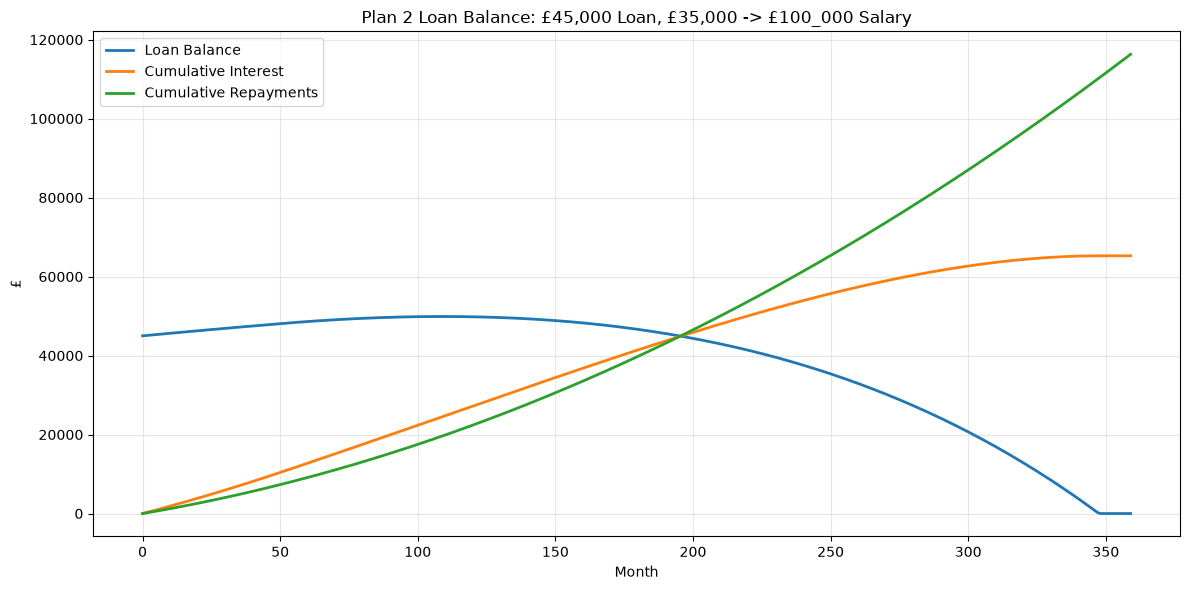

In [32]:
loan_balance = lp.loan_balance[0]
cumulative_interest = np.cumsum(lp.interest_accrued[0])
cumulative_repayment = np.cumsum(lp.base_repayment[0])

months = np.arange(len(loan_balance))

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(months, loan_balance, label="Loan Balance", linewidth=2)
ax.plot(months, cumulative_interest, label="Cumulative Interest", linewidth=2)
ax.plot(months, cumulative_repayment, label="Cumulative Repayments", linewidth=2)

ax.set_xlabel("Month")
ax.set_ylabel("£")
ax.set_title("Plan 2 Loan Balance: £45,000 Loan, £35,000 -> £100_000 Salary")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()